# Training a Spiking Neural Network

A spiking network unrolled over time *is* a recurrent network, so it can be trained with
backpropagation through time. The one obstacle is the spike itself: a threshold function has zero
gradient almost everywhere, so gradients cannot flow back through it. The standard remedy is a
**surrogate gradient** — use the hard threshold on the forward pass, but a smooth approximation
for the backward pass.

This tutorial trains a small spiking classifier end to end: define the network with a surrogate
spike function, generate a synthetic spike dataset, and optimise it with `braintools.optim` and
`brainstate.transform.grad`.

In [1]:
import brainunit as u
import jax.numpy as jnp
import matplotlib.pyplot as plt

import brainstate
import brainpy
import braintools

brainstate.random.seed(0)
brainstate.environ.set(dt=1.0 * u.ms)

num_inputs, num_hidden, num_outputs = 100, 4, 2
num_steps, batch_size = 100, 128
brainstate.__version__

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


'0.4.0'

## The network

The classifier has three stages: an input projection (`Linear` followed by an `Expon` synapse), a
recurrent `LIF` layer, and a readout (`Linear` into an `Expon` output). The crucial detail is
`spk_fun=braintools.surrogate.ReluGrad()` on the `LIF` layer — this is what makes the spike
differentiable for training. Weights are initialised with `braintools.init`.

In [2]:
class SNN(brainstate.nn.Module):
    def __init__(self, n_in, n_rec, n_out):
        super().__init__()
        decay = 1 - u.math.exp(-brainstate.environ.get_dt() / (1 * u.ms))
        self.i2r = brainstate.nn.Sequential(
            brainstate.nn.Linear(
                n_in, n_rec,
                w_init=braintools.init.KaimingNormal(scale=7 * decay, unit=u.mA),
                b_init=braintools.init.ZeroInit(unit=u.mA),
            ),
            brainpy.state.Expon(n_rec, tau=10. * u.ms,
                                g_initializer=braintools.init.Constant(0. * u.mA)),
        )
        self.r = brainpy.state.LIF(
            n_rec, tau=20 * u.ms, V_rest=0 * u.mV, V_reset=0 * u.mV, V_th=1. * u.mV,
            spk_fun=braintools.surrogate.ReluGrad(),   # surrogate gradient for the spike
        )
        self.r2o = brainstate.nn.Linear(n_rec, n_out, w_init=braintools.init.KaimingNormal())
        self.o = brainpy.state.Expon(n_out, tau=10. * u.ms,
                                     g_initializer=braintools.init.Constant(0.))

    def update(self, spike):
        # one time step: input projection -> recurrent spikes -> readout
        return self.o(self.r2o(self.r(self.i2r(spike))))

net = SNN(num_inputs, num_hidden, num_outputs)

## A synthetic dataset

Each example is a `num_steps x num_inputs` array of Poisson spikes; the label is a random binary
class. The data is intentionally trivial — the point is the training mechanics, not the task.

In [3]:
firing_rate = 5 * u.Hz
x_data = brainstate.random.rand(num_steps, batch_size, num_inputs) < firing_rate * brainstate.environ.get_dt()
y_data = u.math.asarray(brainstate.random.rand(batch_size) < 0.5, dtype=int)
print('input spikes:', x_data.shape, '| labels:', y_data.shape)

input spikes: (100, 128, 100) | labels: (128,)


## Loss, optimizer, and the training step

The loss runs the network over all time steps with `for_loop`, averages the readout over time,
and applies a cross-entropy. The training step re-initialises the network state for each batch,
differentiates the loss with respect to the parameters (backpropagation through time), and
applies an Adam update — the whole thing wrapped in `jit`.

In [4]:
def accuracy():
    brainstate.nn.init_all_states(net, batch_size=batch_size)
    outs = brainstate.transform.for_loop(net.update, x_data)
    pred = u.math.argmax(u.math.max(outs, axis=0), axis=1)   # max over time, argmax over class
    return float(u.math.mean(pred == y_data))

print(f'accuracy before training: {accuracy():.3f}')

accuracy before training: 0.438


In [5]:
optimizer = braintools.optim.Adam(lr=3e-3)
optimizer.register_trainable_weights(net.states(brainstate.ParamState))

def loss_fn():
    outs = brainstate.transform.for_loop(net.update, x_data)
    outs = u.math.mean(outs, axis=0)
    return braintools.metric.softmax_cross_entropy_with_integer_labels(outs, y_data).mean()

@brainstate.transform.jit
def train_step():
    brainstate.nn.init_all_states(net, batch_size=batch_size)
    grads, loss = brainstate.transform.grad(
        loss_fn, net.states(brainstate.ParamState), return_value=True)()
    optimizer.update(grads)
    return loss

## Training

Each call to `train_step` is one epoch over the batch. The loss falls steadily as the surrogate
gradient drives the weights.

In [6]:
losses = []
for epoch in range(1, 801):
    losses.append(float(train_step()))
    if epoch % 100 == 0:
        print(f'epoch {epoch:4d} | loss {losses[-1]:.4f}')

epoch  100 | loss 0.5279


epoch  200 | loss 0.3692


epoch  300 | loss 0.2669


epoch  400 | loss 0.1996


epoch  500 | loss 0.1493


epoch  600 | loss 0.1111


epoch  700 | loss 0.0834


epoch  800 | loss 0.0628


accuracy after training: 0.844


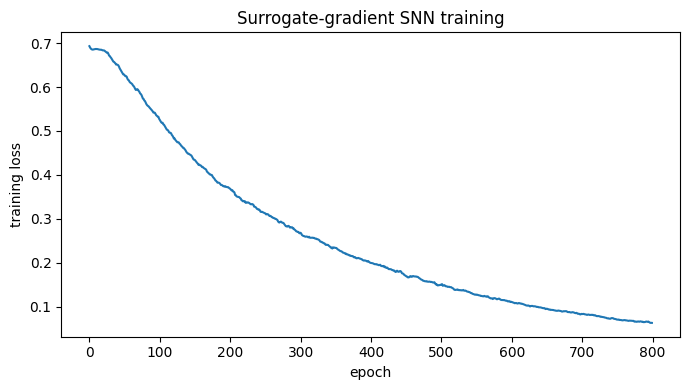

In [7]:
print(f'accuracy after training: {accuracy():.3f}')

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('training loss')
plt.title('Surrogate-gradient SNN training')
plt.tight_layout()
plt.show()

## Summary

- A spiking network is a recurrent network in time; train it with backpropagation through time.
- The non-differentiable spike is handled by a **surrogate gradient**, supplied to the neuron
  model as `spk_fun=braintools.surrogate.ReluGrad()` (other surrogates are available).
- The loop over time is a `brainstate.transform.for_loop`; `grad` differentiates through it, and a
  `braintools.optim` optimizer applies the updates — exactly the [training pattern from the core
  track](../core/07_training_and_metrics.ipynb), now unrolled over time.

### See also

- [Building a spiking neural network](04_building_an_snn.ipynb) — simulating (not training) an SNN.
- [Training and metrics](../core/07_training_and_metrics.ipynb) — the underlying optimization loop.
- The [brain-dynamics gallery](../../examples/brain_dynamics/index.rst) — complete SNN applications.